# Physics-Informed Hybrid Observables on Directional Advection

This notebook demonstrates hybrid physics-informed observables on directional
grid advection with three models that share the **same total** ``latent_dim``:

1. **Pure GNN** — learned lifting only (full width is GNN).
2. **Laplacian preset hybrid** — prepends ``L_norm @ x`` via
   ``physics_preset='graph_laplacian'``.
3. **Custom hybrid** — prepends west/north neighbor states via a user-defined
   ``physics_lifting_fn``.

The benchmark is
:class:`~koopman_graph.datasets.AnisotropicAdvectionGridBenchmark`, where node
features evolve through **asymmetric** weighted neighbor mixing (west/north
directions dominate) with self-retention — advection-like dynamics on a grid,
not exact symmetric Laplacian diffusion. A custom directional lift is
**motivated by** that update rule (west/north neighbors); a Laplacian preset
instead injects a **symmetric** structural prior. Which prior helps is
seed- and horizon-dependent — do not assume directional features must win.

**Scope:** Primary goal is the API/contract (presets, custom callables,
``save``/``load``). Held-out RMSE is a **cautionary matched-capacity**,
single-seed illustration (``DATA_SEED`` / ``MODEL_SEED`` below) — not a
general hybrid-vs-GNN benchmark claim. Long-horizon RMSE remains seed-sensitive
for unconstrained dense ``K``.


## Workflow

1. **Encode (GNN lifting):** A GCN encoder maps node features into a learned
   latent ``z_gnn``.
2. **Physics lift (optional):** supply either a built-in preset
   (``physics_preset='graph_laplacian'``) or a custom callable
   ``physics_lifting_fn(data)`` returning ``(num_nodes, physics_dim)`` features.
   Physics features are prepended: ``z = [z_physics || z_gnn]``.
3. **Koopman step:** A learned matrix ``K`` advances the combined latent state.
4. **Decode:** A GCN decoder maps latent states back to physical features.

Set ``physics_dim`` explicitly and ensure
``latent_dim = physics_dim + encoder.latent_dim``. For a fair width comparison,
fix a shared ``TOTAL_LATENT`` and set
``encoder.latent_dim = TOTAL_LATENT - physics_dim`` (pure GNN uses
``physics_dim = 0``). Custom callables are not serialized — re-supply
``physics_lifting_fn`` on
:meth:`~koopman_graph.model.GraphKoopmanModel.load`.


In [1]:
import os
import tempfile
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import temporal_split
from koopman_graph.datasets import AnisotropicAdvectionGridBenchmark

## 1. Data and train/val/test split

We generate 100 snapshots on an 8×8 grid. The test split must be long enough
for 12-step open-loop rollouts (``evaluate`` requires
``num_timesteps > max(horizons)``), so we allocate 25% of snapshots to test.

**Matched capacity:** All three models use the same total ``latent_dim``
(``TOTAL_LATENT``). Hybrids allocate ``physics_dim`` channels to physics
features and the remainder to the GNN encoder; the pure GNN uses the full
width as learned lifting. Decoder width and ``K`` size therefore match.

**Seed policy:** ``DATA_SEED`` fixes the benchmark trajectory and split;
``MODEL_SEED`` is reset before each model construction so initialization RNG
does not leak across fits. Results below are one seed / one split — illustrative
only.


In [2]:
DATA_SEED = 0
MODEL_SEED = 1

NUM_TIMESTEPS = 100
NUM_ROWS = 8
NUM_COLS = 8
IN_CHANNELS = 3
# Shared total latent width (matched capacity across pure / hybrid models).
# Anchor on the Laplacian hybrid's natural split (physics_dim = in_channels,
# GNN remainder = 16) so all three models share latent_dim = 19.
CUSTOM_PHYSICS_DIM = 2 * IN_CHANNELS  # west + north neighbor states
LAPLACIAN_PHYSICS_DIM = IN_CHANNELS  # L_norm @ x
GNN_REMAINDER_FOR_LAPLACIAN = 16
TOTAL_LATENT = GNN_REMAINDER_FOR_LAPLACIAN + LAPLACIAN_PHYSICS_DIM  # 19
HIDDEN = 32
TIME_STEP = 0.1
EPOCHS = 50
LR = 5e-3
EVAL_HORIZONS = [3, 6, 12]

torch.manual_seed(DATA_SEED)
sequence = AnisotropicAdvectionGridBenchmark.generate(
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    seed=DATA_SEED,
)
split = temporal_split(
    sequence,
    train_ratio=0.6,
    val_ratio=0.15,
    test_ratio=0.25,
)

print(
    f"nodes={sequence.num_nodes}, "
    f"train={split.train.num_timesteps}, "
    f"val={split.val.num_timesteps}, "
    f"test={split.test.num_timesteps}"
)
print(
    f"TOTAL_LATENT={TOTAL_LATENT} "
    f"(Laplacian physics_dim={LAPLACIAN_PHYSICS_DIM}, "
    f"custom physics_dim={CUSTOM_PHYSICS_DIM})"
)


nodes=64, train=60, val=15, test=25
TOTAL_LATENT=19 (Laplacian physics_dim=3, custom physics_dim=6)


## 2. Custom physics lifting function

The benchmark's dominant transport is **westward and northward** neighbor
mixing. A symmetric Laplacian smooths equally in all directions; here we inject
the **neighbor states themselves** along those axes as a prior *motivated by*
the asymmetric update rule (not guaranteed to outperform):

- western neighbor ``x_west`` (self-copy on the western boundary)
- northern neighbor ``x_north`` (self-copy on the northern boundary)

Concatenated, this yields ``physics_dim = 2 * in_channels`` features — distinct
from the Laplacian preset. Forecast quality for either prior is seed- and
horizon-dependent under unconstrained dense ``K``.

**Why not deltas?** Features like ``x_west - x`` look like an advection
gradient, but hybrid physics coordinates are encoded **once** and then evolved
linearly by ``K``. Difference features shrink as the field smooths and are easy
for an unconstrained ``K`` to amplify over long rollouts. Absolute neighbor
values are a stabler directional coordinate choice for multi-step forecasting
than raw deltas — still not a claim that this prior must beat pure GNN.


In [3]:
def directional_advection_features(data: Data) -> torch.Tensor:
    """West- and north-neighbor states for hybrid lifting.

    Boundary nodes without a west/north neighbor copy their own state.
    Absolute neighbor values are stabler long-horizon physics coordinates
    than raw deltas ``x_neighbor - x``, which shrink as the field smooths
    and are easy for unconstrained ``K`` to amplify in open-loop rollout.
    """
    x = data.x
    west = torch.empty_like(x)
    north = torch.empty_like(x)
    for row in range(NUM_ROWS):
        for col in range(NUM_COLS):
            node = row * NUM_COLS + col
            if col > 0:
                west[node] = x[row * NUM_COLS + (col - 1)]
            else:
                west[node] = x[node]
            if row > 0:
                north[node] = x[(row - 1) * NUM_COLS + col]
            else:
                north[node] = x[node]
    return torch.cat([west, north], dim=-1)


assert CUSTOM_PHYSICS_DIM == 2 * IN_CHANNELS
print(f"Laplacian preset physics_dim={LAPLACIAN_PHYSICS_DIM}")
print(f"Custom directional physics_dim={CUSTOM_PHYSICS_DIM}")
print(
    f"Matched TOTAL_LATENT={TOTAL_LATENT} → "
    f"pure gnn={TOTAL_LATENT}, "
    f"Laplacian gnn={TOTAL_LATENT - LAPLACIAN_PHYSICS_DIM}, "
    f"custom gnn={TOTAL_LATENT - CUSTOM_PHYSICS_DIM}"
)


Laplacian preset physics_dim=3
Custom directional physics_dim=6
Matched TOTAL_LATENT=19 → pure gnn=19, Laplacian gnn=16, custom gnn=13


## 3. Train pure GNN vs hybrid models (preset and custom)

All three models share ``TOTAL_LATENT``, hidden width, and training
hyperparameters. The Laplacian hybrid uses ``physics_preset='graph_laplacian'``;
the custom hybrid passes ``physics_lifting_fn=directional_advection_features``
with no preset. Encoder width is ``TOTAL_LATENT - physics_dim`` so the comparison
is capacity-matched.


In [4]:
def build_model(
    *,
    physics_dim: int,
    physics_preset: str | None = None,
    physics_lifting_fn=None,
) -> GraphKoopmanModel:
    gnn_latent_dim = TOTAL_LATENT - physics_dim
    return GraphKoopmanModel(
        encoder=GNNEncoder(
            in_channels=IN_CHANNELS,
            hidden_channels=HIDDEN,
            latent_dim=gnn_latent_dim,
        ),
        decoder=GNNDecoder(
            latent_dim=TOTAL_LATENT,
            hidden_channels=HIDDEN,
            out_channels=IN_CHANNELS,
        ),
        latent_dim=TOTAL_LATENT,
        time_step=TIME_STEP,
        physics_preset=physics_preset,
        physics_lifting_fn=physics_lifting_fn,
        physics_dim=physics_dim,
    )


torch.manual_seed(MODEL_SEED)
pure_model = build_model(physics_dim=0)

torch.manual_seed(MODEL_SEED)
laplacian_model = build_model(
    physics_dim=LAPLACIAN_PHYSICS_DIM,
    physics_preset="graph_laplacian",
)

torch.manual_seed(MODEL_SEED)
custom_model = build_model(
    physics_dim=CUSTOM_PHYSICS_DIM,
    physics_lifting_fn=directional_advection_features,
)

assert (
    pure_model.latent_dim
    == laplacian_model.latent_dim
    == custom_model.latent_dim
    == TOTAL_LATENT
)
print(
    f"Matched total latent_dim={TOTAL_LATENT}; "
    f"pure gnn={pure_model.gnn_latent_dim}; "
    f"Laplacian hybrid gnn={laplacian_model.gnn_latent_dim} "
    f"+ physics={laplacian_model.physics_dim}; "
    f"custom hybrid gnn={custom_model.gnn_latent_dim} "
    f"+ physics={custom_model.physics_dim}"
)

pure_history = pure_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)
laplacian_history = laplacian_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)
custom_history = custom_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)

print(f"Pure GNN final val loss:      {pure_history.val_loss[-1]:.6f}")
print(f"Laplacian hybrid val loss:    {laplacian_history.val_loss[-1]:.6f}")
print(f"Custom directional val loss:  {custom_history.val_loss[-1]:.6f}")


Matched total latent_dim=19; pure gnn=19; Laplacian hybrid gnn=16 + physics=3; custom hybrid gnn=13 + physics=6
Pure GNN final val loss:      0.003310
Laplacian hybrid val loss:    0.002593
Custom directional val loss:  0.003276


## 4. Validation loss and rollout comparison

The **left panel** tracks one-step validation loss during ``fit``. The **right
panel** is a **cautionary matched-capacity** open-loop RMSE chart on the test
split via :meth:`~koopman_graph.model.GraphKoopmanModel.evaluate` — useful for
seeing how width allocation interacts with rollout, **not** for ranking hybrid
methods in general.

Because total ``latent_dim`` matches, differences reflect how width is allocated
(physics vs GNN) rather than raw capacity. One-step val loss and long-horizon
RMSE can still disagree: physics features are encoded once and then evolved
linearly by ``K``.

**This run:** final val losses are similar (~3e-3), yet at horizon 12 the custom
directional hybrid is **worst** (RMSE ≈ 1.12) while the Laplacian hybrid stays
near ≈ 0.19 and pure GNN lands in between (≈ 0.50). That is an open-loop
operator / multi-step generalization failure for the custom model on this seed —
not a failed fit. Horizon winners can flip; treat the bars as illustration only.

Rollout RMSE need not grow monotonically with horizon: metrics are averaged over
multiple forecast origins, and transient mismatch can peak at intermediate
horizons before partially recovering.


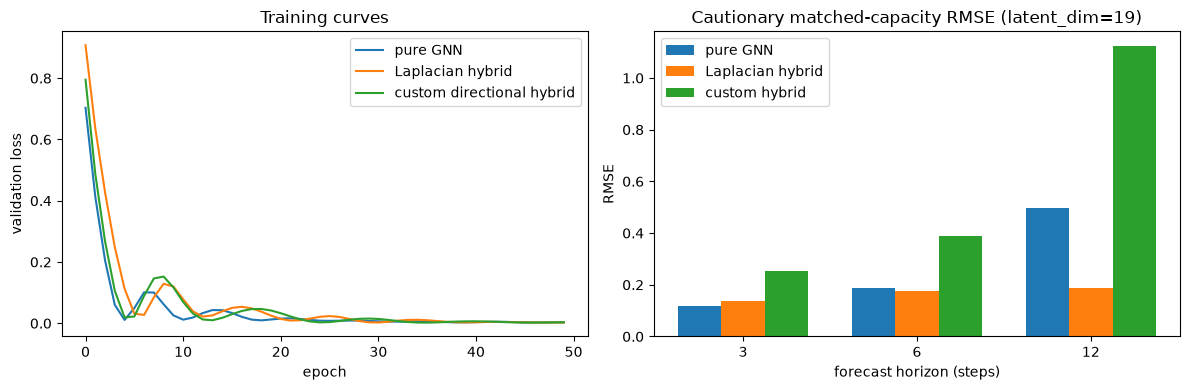

Cautionary matched-capacity horizon RMSE (pure / Laplacian / custom; total latent_dim=19):
  h= 3: 0.116083 / 0.137501 / 0.251425
  h= 6: 0.187833 / 0.176280 / 0.387859
  h=12: 0.497848 / 0.187716 / 1.124227


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(pure_history.val_loss, label="pure GNN")
axes[0].plot(laplacian_history.val_loss, label="Laplacian hybrid")
axes[0].plot(custom_history.val_loss, label="custom directional hybrid")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation loss")
axes[0].set_title("Training curves")
axes[0].legend()

pure_eval = pure_model.evaluate(split.test, horizons=EVAL_HORIZONS)
laplacian_eval = laplacian_model.evaluate(split.test, horizons=EVAL_HORIZONS)
custom_eval = custom_model.evaluate(split.test, horizons=EVAL_HORIZONS)

pure_by_h = {metric.horizon: metric for metric in pure_eval.horizons}
laplacian_by_h = {metric.horizon: metric for metric in laplacian_eval.horizons}
custom_by_h = {metric.horizon: metric for metric in custom_eval.horizons}
pure_rmse = [pure_by_h[h].rmse for h in EVAL_HORIZONS]
laplacian_rmse = [laplacian_by_h[h].rmse for h in EVAL_HORIZONS]
custom_rmse = [custom_by_h[h].rmse for h in EVAL_HORIZONS]

bar_x = range(len(EVAL_HORIZONS))
bar_width = 0.25
axes[1].bar(
    [i - bar_width for i in bar_x],
    pure_rmse,
    width=bar_width,
    label="pure GNN",
)
axes[1].bar(
    list(bar_x),
    laplacian_rmse,
    width=bar_width,
    label="Laplacian hybrid",
)
axes[1].bar(
    [i + bar_width for i in bar_x],
    custom_rmse,
    width=bar_width,
    label="custom hybrid",
)
axes[1].set_xticks(list(bar_x))
axes[1].set_xticklabels([str(h) for h in EVAL_HORIZONS])
axes[1].set_xlabel("forecast horizon (steps)")
axes[1].set_ylabel("RMSE")
axes[1].set_title(f"Cautionary matched-capacity RMSE (latent_dim={TOTAL_LATENT})")
axes[1].legend()

fig.tight_layout()
plt.show()

print(
    f"Cautionary matched-capacity horizon RMSE "
    f"(pure / Laplacian / custom; total latent_dim={TOTAL_LATENT}):"
)
for horizon in EVAL_HORIZONS:
    pure = pure_by_h[horizon].rmse
    laplacian = laplacian_by_h[horizon].rmse
    custom = custom_by_h[horizon].rmse
    print(
        f"  h={horizon:2d}: {pure:.6f} / {laplacian:.6f} / {custom:.6f}"
    )


## 5. Save and load with a custom ``physics_lifting_fn``

Checkpoints store ``physics_dim`` but **not** the callable itself. After
``save``, pass the same function to ``load`` so hybrid encoding is restored.

In [6]:
initial = split.test[0]
steps = 3
before_save = custom_model.predict(initial, steps=steps)

with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_path = Path(tmpdir) / "custom_directional_hybrid.pt"
    custom_model.save(checkpoint_path)
    loaded_custom = GraphKoopmanModel.load(
        checkpoint_path,
        physics_lifting_fn=directional_advection_features,
    )

after_load = loaded_custom.predict(initial, steps=steps)
max_diff = max(
    (before.x - after.x).abs().max().item()
    for before, after in zip(before_save, after_load, strict=True)
)
print(f"Loaded physics_dim={loaded_custom.physics_dim} (preset={loaded_custom.physics_preset})")
print(f"Max |x_before - x_after_load| over {steps} steps: {max_diff:.2e}")
assert max_diff < 1e-5, "save/load round-trip predictions should match"
print("save/load round-trip OK")

Loaded physics_dim=6 (preset=None)
Max |x_before - x_after_load| over 3 steps: 0.00e+00
save/load round-trip OK


## Takeaways

- **Hybrid lifting** concatenates structural and learned features:
  ``z = [z_physics || GNN(x)]``. Use a built-in preset
  (``physics_preset='graph_laplacian'``) or a custom
  ``physics_lifting_fn(data)`` returning ``(num_nodes, physics_dim)`` tensors.
- **Custom example:** ``directional_advection_features`` injects west/north
  neighbor **states** (``physics_dim = 2 * in_channels``), a prior *motivated by*
  directional advection — not a guarantee of better forecasts. Prefer absolute
  neighbor values over raw deltas for long rollouts: deltas shrink as the
  field smooths and unconstrained ``K`` can amplify them by horizon 12.
- **API:** set ``physics_dim`` explicitly;
  ``latent_dim = physics_dim + encoder.latent_dim``. For fair comparisons, fix
  a shared ``TOTAL_LATENT`` and shrink the GNN remainder when physics channels
  are added. Checkpoints store ``physics_dim`` and optional ``physics_preset``;
  **re-supply custom callables** on
  :meth:`~koopman_graph.model.GraphKoopmanModel.load`.
- **This run (cautionary):** all models share ``TOTAL_LATENT=19`` and reach
  similar one-step val loss, but matched-capacity open-loop RMSE at h=12 is
  roughly pure ≈ 0.50 / Laplacian ≈ 0.19 / **custom ≈ 1.12**. The custom hybrid
  is worst here despite a successful fit — multi-step ``K`` rollout, not
  training failure. Single-seed (``DATA_SEED`` / ``MODEL_SEED``); do not read
  the bar chart as a general hybrid-vs-GNN ranking. Dense ``K`` remains
  seed-sensitive.
- **Stricter studies:** average across seeds, use structural stability modes
  (``schur`` / ``dissipative``), or report confidence intervals before claiming
  method-level gains.
- **Related:** ``04_grid_attention.ipynb`` shows GAT can help when neighbor
  influence is asymmetric; physics priors complement attention, not replace it.
